In [1]:
# ニューラルネットワークの学習
# データから学習する
# データ駆動
# 訓練データとテストデータ
# 損失関数

In [2]:
# 2乗和誤差の実装
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

In [4]:
# 「2」を正解とする
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# 「2」の確率が最も高い場合
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(mean_squared_error(np.array(y), np.array(t)))

0.09750000000000003


In [5]:
# 交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [7]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338


In [8]:
# ミニバッチ学習
# MNISTデータセットを読み込む
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [10]:
# ランダムに10枚だけ抜き出す
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

print(x_batch.shape)
print(t_batch.shape)

(10, 784)
(10, 10)


In [11]:
# 【バッチ対応版】交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y)) / batch_size

In [12]:
# 教師データがラベルとしてあたえられた場合
# 交差エントロピー誤差の実装
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

In [14]:
# なぜ損失関数を設定するのか？
# 数値微分
# 微分

In [15]:
# 数値微分の実装
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2*h)

In [17]:
# 数値微分の例
def function_1(x):
    return 0.01*x**2 + 0.1*x

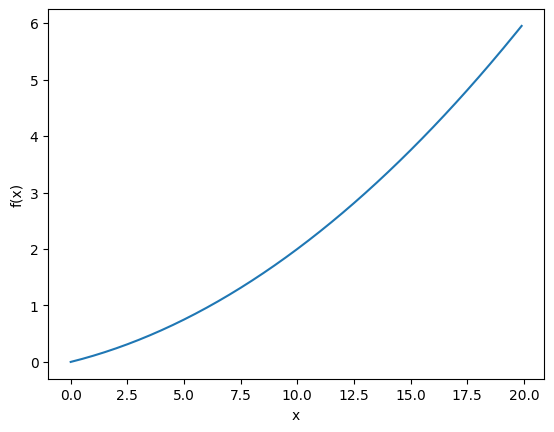

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1) # 0から20まで、0.1刻みのx配列
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [19]:
# 関数の微分を計算してみる
numerical_diff(function_1, 5)

0.1999999999990898

In [20]:
numerical_diff(function_1, 10)

0.2999999999986347

In [21]:
# 偏微分の実装
def function_2(x):
    return x[0]**2 + x[1]**2


In [23]:
# 勾配
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]
        # f(x+h)の計算
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h)の計算
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 値を元に戻す

    return grad

In [24]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [25]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [26]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])